# 04 — XGBoost (weekly silver volatility)

XGBoost on the **same HAR + EXOG feature set** as the Random Forest notebook, so the
two tree models are directly comparable — this mirrors the aligned
`weekly/04_random_forest.ipynb` / `weekly/05_xgboost.ipynb` pair on the returns side.

Hyperparameters are tuned on the validation split, then the model is re-fit on
train+val. Features come from `volatility_weekly.csv` — run `00_features.ipynb` first.


## Setup


In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import ParameterGrid
from vol_utils import vol_evaluate, vol_period_metrics, vol_diebold_mariano, walk_forward
from eval_utils import PERIODS
import warnings; warnings.filterwarnings('ignore')

SEED = 42
plt.rcParams['figure.figsize'] = (10, 4)

frame = pd.read_csv('../../data/processed/volatility_weekly.csv',
                    parse_dates=['Date']).set_index('Date')
train_df = frame[frame['split'] == 'train']
val_df   = frame[frame['split'] == 'val']
test_df  = frame[frame['split'] == 'test']
trval_df = frame[frame['split'] != 'test']

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL  = FEATS_HAR + FEATS_EXOG
print('features:', FEATS_ALL)

features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1', 'gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 1. Hyperparameter tuning

Small grid search over tree count / depth / learning rate. Each configuration is fit on
the train split and scored by RMSE on the validation split; the lowest-RMSE
configuration is kept.


In [2]:
y_tr = train_df['target']; y_v = val_df['target']

def tune_xgb(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5],
                          'learning_rate': [0.03, 0.1]})
    best = (np.inf, None)
    for p in grid:
        m = XGBRegressor(random_state=SEED, verbosity=0, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]:
            best = (rmse, p)
    return best[1]

xgb_best = tune_xgb(train_df[FEATS_ALL], y_tr, val_df[FEATS_ALL], y_v)
print('XGB best params:', xgb_best)


XGB best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


## 2. Refit on train+val and evaluate

The best configuration is re-fit on train+val combined, then scored once on the test
set.


In [3]:
y_test    = test_df['target'].values
prev_test = test_df['rv_w_lag1'].values

# Single-fit on train+val with the tuned hyperparameters; keeps a canonical `xgb`
# model around for §4 feature-importance interpretation (gain importance).
xgb = XGBRegressor(random_state=SEED, verbosity=0, importance_type='gain',
                   **xgb_best).fit(trval_df[FEATS_ALL], trval_df['target'])
xgb_pred_single = xgb.predict(test_df[FEATS_ALL])

# Walk-forward XGB: refit every 4 weeks on all data up to t-1 (expanding window),
# frozen hyperparameters from §1.
def _xgb_fit(X, y, params=xgb_best):
    return XGBRegressor(random_state=SEED, verbosity=0, **params).fit(X, y)

xgb_pred = walk_forward(frame, test_df.index, FEATS_ALL, fit_fn=_xgb_fit, refit_every=4)

results = [vol_evaluate('XGB (HAR+EXOG)', y_test, xgb_pred, prev_test)]

# Single-fit RMSE for reference.
print(f'\nSingle-fit XGB (HAR+EXOG) RMSE (for reference): '
      f'{np.sqrt(((y_test - xgb_pred_single)**2).mean()):.5f}    '
      f'walk-forward RMSE: {np.sqrt(((y_test - xgb_pred)**2).mean()):.5f}')

XGB (HAR+EXOG)                  RMSE=0.03436  MAE=0.01776  R2=+0.184  DCA=0.686

Single-fit XGB (HAR+EXOG) RMSE (for reference): 0.03702    walk-forward RMSE: 0.03436


## 3. DM vs the Naïve floor — does XGB beat $\text{RV}_{t-1}$?

The chapter's central question, restated for the gradient-boosted model: is weekly
silver volatility predictable beyond last week's value? Diebold-Mariano (1995) with
Newey-West (1987) lag-1 variance via `vol_diebold_mariano`; negative DM = XGB has lower
loss.

**QLIKE is the primary loss.** Weekly silver RV is heavy-tailed enough that under
squared-error loss a handful of extreme weeks dominate the differential and inflate the
DM variance, so an RMSE improvement that is real and steady can still fail an MSE-DM
test. The volatility-forecasting literature (Patton 2011) reports forecasts under
**QLIKE**, a proxy-robust ratio loss; squared-error DM is kept underneath only as a
reference. The same comparison is collected across models in `evaluation.ipynb` §4.


In [4]:
# Diebold-Mariano: XGB (HAR+EXOG) vs the Naive RV_{t-1} floor.
print('QLIKE loss  --  primary test:')
vol_diebold_mariano(y_test, xgb_pred, prev_test, 'XGB (HAR+EXOG)', 'Naive', loss='qlike')

print('\nSquared-error loss  --  reference:')
vol_diebold_mariano(y_test, xgb_pred, prev_test, 'XGB (HAR+EXOG)', 'Naive', loss='mse');


QLIKE loss  --  primary test:
XGB (HAR+EXOG)               vs Naive         [qlike]  DM=-1.466  p=0.143  (ns)  -> winner: tie

Squared-error loss  --  reference:
XGB (HAR+EXOG)               vs Naive         [mse  ]  DM=-1.117  p=0.264  (ns)  -> winner: tie


## 4. Feature importance

Gain-based importance — the average gain in accuracy each feature brings to the splits
it appears in. As with the Random Forest, the question is whether any EXOG cross-asset
RV earns non-trivial importance alongside the HAR lags.


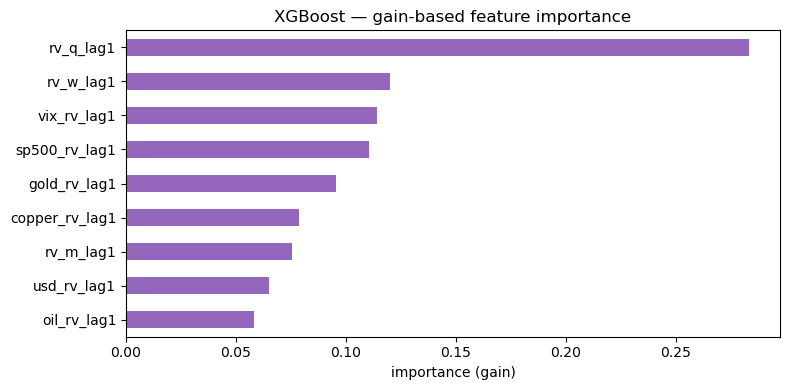

rv_q_lag1         0.2832
rv_w_lag1         0.1198
vix_rv_lag1       0.1140
sp500_rv_lag1     0.1104
gold_rv_lag1      0.0955
copper_rv_lag1    0.0787
rv_m_lag1         0.0755
usd_rv_lag1       0.0648
oil_rv_lag1       0.0580
dtype: float32

In [5]:
imp = pd.Series(xgb.feature_importances_, index=FEATS_ALL).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
imp.plot.barh(ax=ax, color='#9467bd')
ax.set_title('XGBoost — gain-based feature importance'); ax.set_xlabel('importance (gain)')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


## 5. Sub-period breakdown

RMSE and DCA split by calendar year, using the shared `PERIODS` definition.


In [6]:
period_xgb = vol_period_metrics(y_test, xgb_pred, prev_test, test_df.index, PERIODS)
period_xgb.to_csv('../../data/processed/period_xgb_volatility.csv')
period_xgb.round(4)


,n,RMSE,MAE,DCA
Period,,,,
2023 (choppy),52,0.0151,0.0114,0.6731
2024 (bull start),52,0.0192,0.0149,0.7308
2025 (bull run),52,0.0269,0.0182,0.6538
2026 (YTD),19,0.0853,0.0417,0.6842
── Full test ──,175,0.0344,0.0178,0.6857


## 6. Ablations

Same ablation ladder as the HAR-RV ablation in `02_har` §5 and the Random Forest
ablation in `03_random_forest` §6, with XGBoost as the model. Running the same rungs
in three model classes (OLS, RF, XGB) makes the linear-vs-nonlinear contribution
comparable rung-by-rung.

| Rung | Tests |
|---|---|
| `XGB (HAR)` | XGB on HAR features only — the bare baseline |
| `XGB (HAR+EXOG)` | full cross-asset spillover |
| `XGB (HAR+Attention)` | sentiment attention added |
| `XGB (HAR+SentIntensity)` | sentiment intensity (\|tone\|) added |
| `XGB (HAR+Attention+SentIntensity)` | sentiment combined |

Every rung is hyperparameter-tuned independently (`tune_xgb` on the sentiment-available
training subsample) and re-fit on train+val of that subsample, so every rung sees the
same observations and the DM comparison is apples-to-apples. **Primary** QLIKE-DM is
each rung vs the bare `XGB (HAR)` baseline; the **secondary** test pits the combined
sentiment rung against `XGB (HAR+EXOG)`.

In [7]:
FEATS_SENT_ATTN = ['reddit_attention_lag1']
FEATS_SENT_INT  = ['reddit_sent_abs_lag1',
                #    'reddit_sent_disp_lag1'   # dropped per 00_features §2.5 EDA -- mirrors 02_har §5
                   ]
FEATS_SENT      = FEATS_SENT_ATTN + FEATS_SENT_INT

# True-mirror ablation ladder of 02_har §5: sentiment rungs add to bare HAR (no EXOG).
LADDER = {
    'XGB (HAR)':                          FEATS_HAR,
    'XGB (HAR+EXOG)':                     FEATS_HAR + FEATS_EXOG,
    'XGB (HAR+Attention)':                FEATS_HAR + FEATS_SENT_ATTN,
    'XGB (HAR+SentIntensity)':            FEATS_HAR + FEATS_SENT_INT,
    'XGB (HAR+Attention+SentIntensity)':  FEATS_HAR + FEATS_SENT_ATTN + FEATS_SENT_INT,
}

# Common sample: every rung fitted/scored on weeks where Reddit features exist
abl         = frame.dropna(subset=FEATS_SENT)
sent_train  = train_df.dropna(subset=FEATS_SENT)
sent_test   = abl[abl['split'] == 'test']
y_st, prev_st = sent_test['target'].values, sent_test['rv_w_lag1'].values
print(f'ablation sample: train+val={(abl["split"]!="test").sum()}  test={len(sent_test)}\n')

# Tune hyperparams once per rung (frozen across walk-forward refits) and walk forward
# refitting every 4 weeks.
abl_pred, abl_results = {}, []
for name, feats in LADDER.items():
    best = tune_xgb(sent_train[feats], sent_train['target'],
                    val_df[feats],     val_df['target'])
    def _fit(X, y, _b=best):
        return XGBRegressor(random_state=SEED, verbosity=0, **_b).fit(X, y)
    pred = walk_forward(abl, sent_test.index, feats, fit_fn=_fit, refit_every=4)
    abl_pred[name] = pred
    abl_results.append(vol_evaluate(name, y_st, pred, prev_st))

# Primary QLIKE-DM: each rung vs the bare XGB (HAR) baseline -- mirrors 02_har §5
print()
dm = {}
for name in LADDER:
    if name == 'XGB (HAR)':
        continue
    dm[name] = vol_diebold_mariano(y_st, abl_pred[name], abl_pred['XGB (HAR)'],
                                   name, 'XGB (HAR)', loss='qlike')

# Secondary: does the combined sentiment rung beat XGB (HAR+EXOG)?
# Mirrors HAR+Att+Int vs HAR+EXOG.
print()
vol_diebold_mariano(y_st, abl_pred['XGB (HAR+Attention+SentIntensity)'],
                          abl_pred['XGB (HAR+EXOG)'],
                          'XGB+Att+Int', 'XGB+EXOG', loss='qlike')

abl_df = pd.DataFrame(abl_results)
abl_df['dm_qlike']   = abl_df['model'].map(lambda m: dm[m]['dm'] if m in dm else np.nan)
abl_df['dm_qlike_p'] = abl_df['model'].map(lambda m: dm[m]['p']  if m in dm else np.nan)
abl_df.to_csv('../../data/processed/metrics_xgb_sentiment_volatility.csv', index=False)
print('\nSaved metrics_xgb_sentiment_volatility.csv')
abl_df.round(5)

ablation sample: train+val=404  test=174



XGB (HAR)                       RMSE=0.03183  MAE=0.01789  R2=+0.302  DCA=0.690


XGB (HAR+EXOG)                  RMSE=0.03464  MAE=0.01787  R2=+0.174  DCA=0.707


XGB (HAR+Attention)             RMSE=0.03148  MAE=0.01787  R2=+0.317  DCA=0.678


XGB (HAR+SentIntensity)         RMSE=0.03189  MAE=0.01728  R2=+0.300  DCA=0.701


XGB (HAR+Attention+SentIntensity)  RMSE=0.03188  MAE=0.01798  R2=+0.300  DCA=0.707

XGB (HAR+EXOG)               vs XGB (HAR)     [qlike]  DM=+1.368  p=0.171  (ns)  -> winner: tie
XGB (HAR+Attention)          vs XGB (HAR)     [qlike]  DM=-0.007  p=0.994  (ns)  -> winner: tie
XGB (HAR+SentIntensity)      vs XGB (HAR)     [qlike]  DM=-0.997  p=0.319  (ns)  -> winner: tie
XGB (HAR+Attention+SentIntensity) vs XGB (HAR)     [qlike]  DM=+2.191  p=0.028  *     -> winner: XGB (HAR)

XGB+Att+Int                  vs XGB+EXOG      [qlike]  DM=-0.450  p=0.653  (ns)  -> winner: tie

Saved metrics_xgb_sentiment_volatility.csv


,model,rmse,mae,r2,dca,dm_qlike,dm_qlike_p
0,XGB (HAR),0.03183,0.01789,0.30219,0.68966,NaN,NaN
1,XGB (HAR+EXOG),0.03464,0.01787,0.17352,0.70690,1.36817,0.17126
2,XGB (HAR+Attention),0.03148,0.01787,0.31747,0.67816,-0.00728,0.99419
3,XGB (HAR+SentIntensity),0.03189,0.01728,0.29986,0.70115,-0.99733,0.31860
4,XGB (HAR+Attention+SentIntensity),0.03188,0.01798,0.30033,0.70690,2.19119,0.02844


## 7. Permutation importance — OOS view of the combined sentiment rung

The §4 plot above shows **gain** importance for the headline `XGB (HAR+EXOG)` model —
an *in-sample* loss-reduction measure across all the boosting splits. For checking
whether the trees actually *use* the sentiment features out-of-sample, gain is the
wrong tool.

This section adds **permutation importance** (Breiman 2001; sklearn's
`permutation_importance`): shuffle each feature in the test set, measure how much
the test MSE worsens. A feature with high permutation importance is one the model
genuinely relies on for OOS predictions; a feature with permutation importance ≈ 0
contributes nothing to OOS forecast quality even if gain gives it a non-zero score.

Computed for `XGB (HAR+EXOG+Attention+SentIntensity)` so all features (HAR + EXOG +
sentiment) appear in both plots. The contrast between gain (left) and permutation
importance (right) is the diagnostic — features where the two diverge are split-on
by the boosting in-sample but don't help OOS.

Asier: understand the permutation importance and the different types of feature importance.

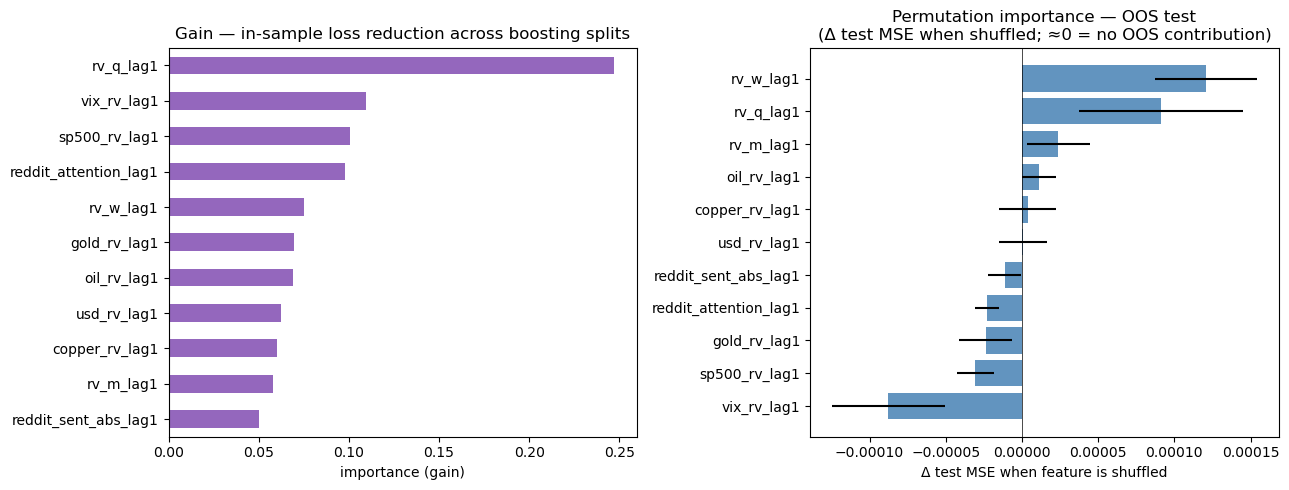

Gain (in-sample) ranking:
rv_q_lag1                0.2473
vix_rv_lag1              0.1095
sp500_rv_lag1            0.1005
reddit_attention_lag1    0.0980
rv_w_lag1                0.0750
gold_rv_lag1             0.0697
oil_rv_lag1              0.0692
usd_rv_lag1              0.0622
copper_rv_lag1           0.0600
rv_m_lag1                0.0581
reddit_sent_abs_lag1     0.0504

Permutation importance (OOS test) ranking:
rv_w_lag1                0.000121
rv_q_lag1                0.000091
rv_m_lag1                0.000024
oil_rv_lag1              0.000011
copper_rv_lag1           0.000004
usd_rv_lag1              0.000001
reddit_sent_abs_lag1    -0.000011
reddit_attention_lag1   -0.000023
gold_rv_lag1            -0.000024
sp500_rv_lag1           -0.000031
vix_rv_lag1             -0.000088


In [8]:
from sklearn.inspection import permutation_importance

# Re-fit the combined sentiment rung canonically on sent_trval (single fit on
# train+val) and compute two importance measures side-by-side on the test set:
#   (a) Gain -- in-sample loss-reduction across all the boosting splits.
#   (b) Permutation importance (Breiman 2001) -- shuffles each test-set feature
#       and measures the rise in test MSE; perm-importance ≈ 0 means the feature
#       contributes nothing to OOS predictions even if gain gives it a non-zero
#       score.
# The contrast is the diagnostic for whether sentiment is genuinely used OOS or
# just split-on in-sample.
combined_feats = FEATS_HAR + FEATS_EXOG + FEATS_SENT_ATTN + FEATS_SENT_INT
sent_trval     = abl[abl['split'] != 'test']

combined_best = tune_xgb(sent_train[combined_feats], sent_train['target'],
                         val_df[combined_feats],     val_df['target'])
model = XGBRegressor(random_state=SEED, verbosity=0, importance_type='gain',
                     **combined_best).fit(sent_trval[combined_feats], sent_trval['target'])

gain = pd.Series(model.feature_importances_, index=combined_feats)
perm = permutation_importance(model, sent_test[combined_feats], y_st,
                              n_repeats=20, random_state=SEED,
                              scoring='neg_mean_squared_error')
perm_mean = pd.Series(perm.importances_mean, index=combined_feats)
perm_std  = pd.Series(perm.importances_std,  index=combined_feats)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
gain.sort_values().plot.barh(ax=ax[0], color='#9467bd')
ax[0].set_title('Gain — in-sample loss reduction across boosting splits')
ax[0].set_xlabel('importance (gain)')

ord_perm = perm_mean.sort_values().index
ax[1].barh(ord_perm, perm_mean[ord_perm], xerr=perm_std[ord_perm],
           color='steelblue', alpha=0.85)
ax[1].axvline(0, color='black', lw=0.5)
ax[1].set_title('Permutation importance — OOS test\n(Δ test MSE when shuffled; ≈0 = no OOS contribution)')
ax[1].set_xlabel('Δ test MSE when feature is shuffled')

plt.tight_layout(); plt.show()

print('Gain (in-sample) ranking:')
print(gain.sort_values(ascending=False).round(4).to_string())
print('\nPermutation importance (OOS test) ranking:')
print(perm_mean.sort_values(ascending=False).round(6).to_string())

## 8. Save outputs

- `metrics_xgb_volatility.csv` — XGBoost headline metrics
- `pred_xgb_volatility.csv` — test-set predictions, consumed by `evaluation.ipynb`
- `metrics_xgb_sentiment_volatility.csv` — the §6 sentiment-ablation table (saved above)

In [9]:
pd.DataFrame(results).to_csv('../../data/processed/metrics_xgb_volatility.csv', index=False)

pred_xgb = pd.DataFrame({'actual': y_test, 'prev': prev_test, 'xgb': xgb_pred}, index=test_df.index)
pred_xgb.to_csv('../../data/processed/pred_xgb_volatility.csv', index_label='Date')
print('Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv')
pd.DataFrame(results).round(5)


Saved metrics_xgb_volatility.csv + pred_xgb_volatility.csv


,model,rmse,mae,r2,dca
0,XGB (HAR+EXOG),0.03436,0.01776,0.18361,0.68571
